# 04 — Benchmark generation, evaluation & plots

End-to-end evaluation of every DEPT similarity method at its **optimized**
parameter (Hungarian `ppm_tolerance` from 03a, Gaussian `σ` from 03b).

1. **Generate** ranked candidate lists for each method/metric over the full
   validation set (peak-overlap prefilter → per-query top-10 with candidate
   SMILES/InChIKey exported).
2. **Figure 2** — grouped **Hits@1/3/10** and **mean Tanimoto@k** across methods.
3. **Figure 5** — Venn overlap of each method's true positives, and a
   rank-fusion **ensemble** that reranks them.
4. **Formula effect** — the same experiment with the reference library
   restricted to compounds sharing the query's molecular formula.

Ranked lists are cached under `RESULTS_DIR/<method>_<metric>/ranked_top10.parquet`;
set `FORCE_REGENERATE = False` to reuse them instead of recomputing.

## 1 · Imports & configuration

In [1]:
import os
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from matplotlib_venn import venn2
from tqdm import tqdm

from dept_similarity.bin_vector import generate_ppm_bins_typed
from dept_similarity.constants import METHOD_NAME_MAPPER, PROCESSED_DATA_DIR, RESULTS_DIR
from dept_similarity.gaussian_vector import generate_gaussian_vector
from dept_similarity.match import get_metrics_at_k
from dept_similarity.prepare import prefilter_pairs_by_peak_overlap, validate_candidate_set
from dept_similarity.spectral_matching import (
    align_dept_peaks_hungarian,
    cosine_from_alignment,
    jaccard_from_alignment,
)

tqdm.pandas()

TOP_K = 10                 # retrieval depth stored per query
K_VALUES = [1, 3, 10]      # hits@k / Tanimoto@k cut-offs reported (Figure 2)
RANDOM_SEED = 42
N_JOBS = -1                # all cores for the fork-parallel generation
FORCE_REGENERATE = False   # reuse cached ranked lists; auto-regenerates any that are missing

## 2 · Load data

Coerce `signed_shifts` to float arrays and suffix each query id with its
InChIKey14 (matching the library id convention `<db>_<id>_<inchikey14>`) so a
query id encodes its own true key.

In [2]:
def _to_float_array(v):
    if isinstance(v, np.ndarray):
        return v.astype(np.float32, copy=False)
    if isinstance(v, list):
        return np.asarray(v, dtype=np.float32)
    if v is None or (np.isscalar(v) and pd.isna(v)):
        return np.asarray([], dtype=np.float32)
    return np.asarray(v, dtype=np.float32)


library_spectra_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/library_data.parquet")
query_spectra_df = pd.read_parquet(f"{PROCESSED_DATA_DIR}/experimental_validation_set.parquet")

library_spectra_df["signed_shifts"] = library_spectra_df["signed_shifts"].map(_to_float_array)
query_spectra_df["signed_shifts"] = query_spectra_df["signed_shifts"].map(_to_float_array)

# Suffix query ids with their InChIKey14 unless already present.
_already = (query_spectra_df["compound_id"].str.split("_").str[-1] == query_spectra_df["inchikey14"]).all()
if not _already:
    query_spectra_df["compound_id"] = query_spectra_df["compound_id"] + "_" + query_spectra_df["inchikey14"]

N_TOTAL_QUERIES = query_spectra_df["compound_id"].nunique()
print({"library_rows": len(library_spectra_df), "query_rows": len(query_spectra_df),
       "unique_queries": N_TOTAL_QUERIES})

{'library_rows': 455289, 'query_rows': 648, 'unique_queries': 648}


## 3 · Optimized parameters (from 03a / 03b)

Read the sweep summaries and pick each method's parameter that maximizes
**Hits@10** — the widest, most stable cut-off (same criterion 03c uses for σ).

In [3]:
OPT_DIR = Path(RESULTS_DIR) / "optimization"

hung_sweep = pd.read_parquet(OPT_DIR / "hungarian" / "summary_hits_at_k.parquet")
HUNG_TOL = float(hung_sweep.loc[hung_sweep["Hits@10 cosine (%)"].idxmax(), "ppm_tolerance"])

gauss_sweep = pd.read_parquet(OPT_DIR / "gaussian" / "summary_hits_at_k.parquet")
GAUSS_SIGMA = float(gauss_sweep.loc[gauss_sweep["Hits@10 (%)"].idxmax(), "sigma"])

print(f"Hungarian ppm_tolerance = {HUNG_TOL} ppm  (03a Hits@10 optimum)")
print(f"Gaussian sigma          = {GAUSS_SIGMA} ppm (03b Hits@10 optimum)")

Hungarian ppm_tolerance = 3.0 ppm  (03a Hits@10 optimum)
Gaussian sigma          = 2.5 ppm (03b Hits@10 optimum)


## 4 · Candidate pre-filter

Screen the full library for each query with the peak-overlap fingerprint
(same prefilter as 03a/03b). `validate_candidate_set` drops any query whose
true library match was filtered out, so it can't skew the metrics.

In [4]:
all_pairs_dict = prefilter_pairs_by_peak_overlap(query_spectra_df, library_spectra_df)
validate_candidate_set(all_pairs_dict)

query_ids = list(all_pairs_dict.keys())
candidate_ids = sorted({cid for cids in all_pairs_dict.values() for cid in cids})
print({"queries": len(query_ids), "unique_candidates": len(candidate_ids),
       "avg_candidates_per_query": round(float(np.mean([len(v) for v in all_pairs_dict.values()])), 0)})

Building peak-overlap index:   0%|          | 0/455289 [00:00<?, ?it/s]

Building peak-overlap index:   0%|          | 1152/455289 [00:00<00:42, 10622.88it/s]

Building peak-overlap index:   1%|          | 2400/455289 [00:00<00:41, 10831.99it/s]

Building peak-overlap index:   1%|          | 3483/455289 [00:00<00:51, 8847.44it/s] 

Building peak-overlap index:   1%|          | 4397/455289 [00:00<00:53, 8448.76it/s]

...

Peak-overlap prefilter: 100%|██████████| 648/648 [00:38<00:00, 16.86it/s]


2026-07-08 17:38:49,645 - INFO - Peak-overlap prefilter: 648 queries × 455289 library = 295027272 total → 64018456 kept (78.3% filtered, 21.7% kept, avg 98794 candidates/query)


2026-07-08 17:39:08,871 - INFO - Candidate-set validation: 9 / 648 checkable queries lost their true match.


2026-07-08 17:39:08,873 - WARNING - Missing true match for query IDs (first 5): ['nmrshiftdb2_20198917_KUAZQDVKQLNFPE', 'nmrshiftdb2_80041941_LBTABPSJONFLPO', 'nmrshiftdb2_10016011_LNETULKMXZVUST', 'nmrshiftdb2_40115990_NROOUNRRNXKDBP', 'nmrshiftdb2_80039380_RTORNQDWFDEDPT']. Loosen ppm_tolerance or set match_multiplicity=False.


{'queries': 639, 'unique_candidates': 452611, 'avg_candidates_per_query': 98979.0}


## 5 · Generate ranked lists per method (optimized parameters)

The prefilter keeps ~100k candidates per query, so this is heavy. The Hungarian
alignment and Gaussian encoding are numba `@njit` **without nogil** (they hold
the GIL), so we parallelize with joblib's **fork** backend: workers inherit the
large library lookups copy-on-write and only a query-id crosses the process
boundary. Ranking uses a **stable** descending argsort so ties keep candidate
order and results are reproducible.

In [5]:
# Shared read-only lookups (inherited copy-on-write by the forked workers).
LIB_SMILES = library_spectra_df.set_index("compound_id")["smiles"].to_dict()
LIB_INCHIKEY = library_spectra_df.set_index("compound_id")["inchikey"].to_dict()
QUERY_PEAKS = query_spectra_df.set_index("compound_id")["signed_shifts"].to_dict()
LIBRARY_PEAKS = library_spectra_df.set_index("compound_id")["signed_shifts"].to_dict()

CAND_ORDER = candidate_ids
CAND_INDEX = {cid: i for i, cid in enumerate(CAND_ORDER)}
CAND_PEAKS = [LIBRARY_PEAKS[cid] for cid in CAND_ORDER]

# Set per vector-method just before its parallel dispatch (fork inherits them).
LIB_NORM = None
QUERY_VEC_NORM = {}


def _row_normalise(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return (matrix / norms).astype(np.float32)


def _encode_candidate_gauss(i):
    return generate_gaussian_vector(CAND_PEAKS[i], sigma=GAUSS_SIGMA)


def _encode_candidate_bins(i):
    return generate_ppm_bins_typed(CAND_PEAKS[i])


def _rank_row(query_id, metric, scores, cand_ids):
    order = np.argsort(-scores, kind="stable")[:TOP_K]
    sel = [cand_ids[i] for i in order]
    return {
        "query_id": query_id,
        "metric_name": metric,
        "candidate_id_list": sel,
        "score_list": scores[order].astype(float).tolist(),
        "candidate_smiles_list": [LIB_SMILES.get(c) for c in sel],
        "candidate_inchikey_list": [LIB_INCHIKEY.get(c) for c in sel],
    }


def _rank_query_vector(query_id):
    cand = sorted(all_pairs_dict[query_id])
    if not cand:
        return None
    scores_all = LIB_NORM @ QUERY_VEC_NORM[query_id]
    idx = np.fromiter((CAND_INDEX[c] for c in cand), dtype=np.int64, count=len(cand))
    return _rank_row(query_id, "cosine", scores_all[idx], cand)


def _rank_query_hungarian(query_id):
    cand = sorted(all_pairs_dict[query_id])
    if not cand:
        return []
    qp = QUERY_PEAKS[query_id]
    cos = np.empty(len(cand)); jac = np.empty(len(cand))
    for i, c in enumerate(cand):
        res = align_dept_peaks_hungarian(qp, LIBRARY_PEAKS[c],
                                         ppm_tolerance=HUNG_TOL, match_multiplicity=True)
        cos[i] = cosine_from_alignment(res, 1)
        jac[i] = jaccard_from_alignment(res, 1)
    return [_rank_row(query_id, "cosine", cos, cand),
            _rank_row(query_id, "jaccard", jac, cand)]


def _save_ranked(method, rows_by_metric):
    for metric, rows in rows_by_metric.items():
        out_dir = Path(RESULTS_DIR) / f"{method}_{metric}"
        out_dir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(rows).to_parquet(out_dir / "ranked_top10.parquet", index=False)


def _needs_run(method, metrics):
    return FORCE_REGENERATE or any(
        not (Path(RESULTS_DIR) / f"{method}_{m}" / "ranked_top10.parquet").exists()
        for m in metrics)


# --- ppm_bins_typed (cosine) ---
if _needs_run("ppm_bins_typed", ["cosine"]):
    LIB_NORM = _row_normalise(np.stack(Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
        delayed(_encode_candidate_bins)(i) for i in range(len(CAND_ORDER)))))
    QUERY_VEC_NORM = {q: _row_normalise(generate_ppm_bins_typed(QUERY_PEAKS[q])[None, :])[0] for q in query_ids}
    rows = [r for r in Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
        delayed(_rank_query_vector)(q) for q in query_ids) if r]
    _save_ranked("ppm_bins_typed", {"cosine": rows})
    print(f"ppm_bins_typed cosine: {len(rows)} queries")

# --- gauss_kernel (cosine) ---
if _needs_run("gauss_kernel", ["cosine"]):
    LIB_NORM = _row_normalise(np.stack(Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
        delayed(_encode_candidate_gauss)(i) for i in range(len(CAND_ORDER)))))
    QUERY_VEC_NORM = {q: _row_normalise(generate_gaussian_vector(QUERY_PEAKS[q], sigma=GAUSS_SIGMA)[None, :])[0] for q in query_ids}
    rows = [r for r in Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
        delayed(_rank_query_vector)(q) for q in query_ids) if r]
    _save_ranked("gauss_kernel", {"cosine": rows})
    print(f"gauss_kernel cosine: {len(rows)} queries")
    LIB_NORM = None  # free the ~3 GB matrix

# --- hungarian_match (cosine + jaccard, one alignment pass) ---
if _needs_run("hungarian_match", ["cosine", "jaccard"]):
    nested = Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
        delayed(_rank_query_hungarian)(q) for q in query_ids)
    flat = [r for chunk in nested for r in chunk]
    _save_ranked("hungarian_match", {
        "cosine": [r for r in flat if r["metric_name"] == "cosine"],
        "jaccard": [r for r in flat if r["metric_name"] == "jaccard"]})
    print(f"hungarian_match cosine+jaccard: {len(flat) // 2} queries")

print("Ranked-list generation complete.")

Ranked-list generation complete.


## 6 · Load ranked lists → Hits@k + mean Tanimoto@k

`get_metrics_at_k` turns each method's ranked lists into Hits@k (matched on
InChIKey14) and the mean Morgan-fingerprint Tanimoto@k of the retrieved
candidates, in one pass.

In [6]:
overall_results = []
for method_metric_dir in tqdm(sorted(os.listdir(RESULTS_DIR))):
    dir_path = f"{RESULTS_DIR}/{method_metric_dir}"
    if not os.path.isdir(dir_path):
        continue
    method = "_".join(method_metric_dir.split("_")[:-1])
    ranked_path = f"{dir_path}/ranked_top10.parquet"
    if not os.path.exists(ranked_path):
        continue  # skip sibling result dirs (analog, class_analysis, noise_robustness, optimization)
    results_df = pd.read_parquet(ranked_path)
    metrics_df = get_metrics_at_k(
        results_df, query_spectra_df=query_spectra_df, library_spectra_df=library_spectra_df,
        k_values=tuple(K_VALUES), with_inchikey14=True, compute_tanimoto=True,
        n_total_queries=N_TOTAL_QUERIES)
    metrics_df["method"] = method
    overall_results.append(metrics_df)

overall_results_df = (
    pd.concat(overall_results, ignore_index=True)
    .rename(columns={"metric_name": "metric", "k": "top_k"}))
overall_results_df["label"] = [
    METHOD_NAME_MAPPER.get(f"{m}_{mt}", f"{m} ({mt})")
    for m, mt in zip(overall_results_df["method"], overall_results_df["metric"])]
overall_results_df

  0%|          | 0/8 [00:00<?, ?it/s]

 38%|███▊      | 3/8 [00:02<00:03,  1.41it/s]

 50%|█████     | 4/8 [00:04<00:04,  1.11s/it]

 62%|██████▎   | 5/8 [00:06<00:04,  1.38s/it]

100%|██████████| 8/8 [00:08<00:00,  1.01it/s]

100%|██████████| 8/8 [00:08<00:00,  1.02s/it]

,metric,top_k,true_positives,total_queries,accuracy,mean_tanimoto,method,label
0,cosine,1,355,648,54.783951,0.714338,gauss_kernel,Gaussian (Cosine)
1,cosine,3,423,648,65.277778,0.514489,gauss_kernel,Gaussian (Cosine)
2,cosine,10,486,648,75.000000,0.383402,gauss_kernel,Gaussian (Cosine)
3,cosine,1,344,648,53.086420,0.707983,hungarian_match,DEPT-Match (Cosine)
4,cosine,3,425,648,65.586420,0.544504,hungarian_match,DEPT-Match (Cosine)
5,cosine,10,483,648,74.537037,0.410075,hungarian_match,DEPT-Match (Cosine)
6,jaccard,1,343,648,52.932099,0.706411,hungarian_match,DEPT-Match (Jaccard)
7,jaccard,3,422,648,65.123457,0.543018,hungarian_match,DEPT-Match (Jaccard)
8,jaccard,10,479,648,73.919753,0.409706,hungarian_match,DEPT-Match (Jaccard)
9,cosine,1,215,648,33.179012,0.556978,ppm_bins_typed,Shift binned (Cosine)


## 7 · Figure 2 — Hits@k across the cosine methods

Hits@1/3/10 for the three cosine methods (Gaussian, DEPT-Match, Shift binned) at
their optimized parameters. (The mean-Tanimoto chart lives in notebook 05 as
Figure 3a.)

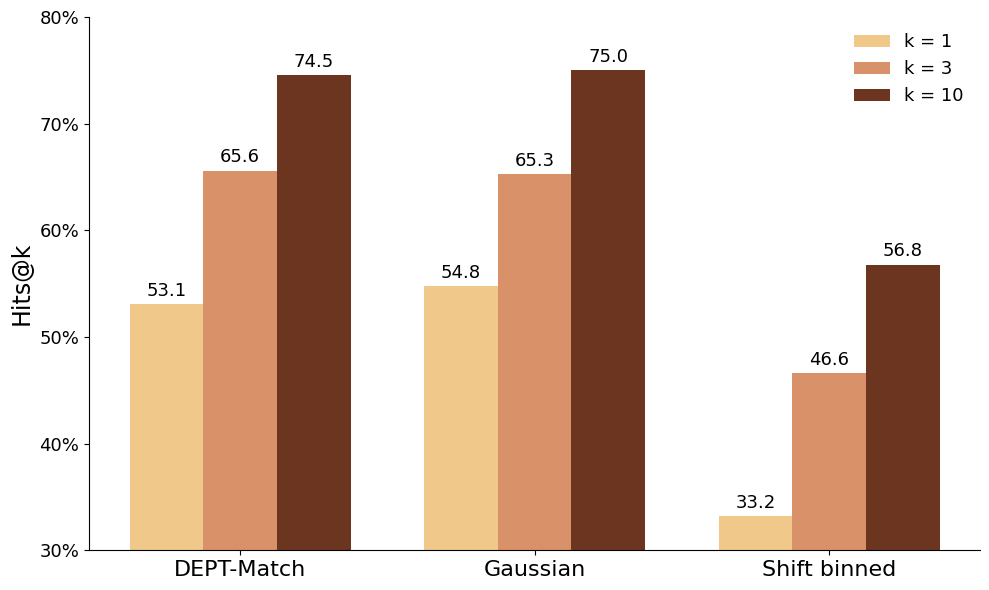

In [7]:
# Figure 2 — Hits@k across the three cosine methods (optimized parameters).
color_map = {1: "#F0C98A", 3: "#D89168", 10: "#6B3520"}
fig2_df = overall_results_df[overall_results_df["metric"] == "cosine"].copy()
fig2_df["disp"] = fig2_df["label"].str.replace(r"\s*\(.*\)$", "", regex=True)
labels = sorted(fig2_df["disp"].unique())
top_k_values = sorted(fig2_df["top_k"].astype(int).unique())
x = np.arange(len(labels))
width = min(0.8 / max(len(top_k_values), 1), 0.25)

# Focus the y-axis on the populated range (bars are truncated, not from 0).
all_vals = fig2_df["accuracy"].to_numpy()
y_lo = float(np.floor((all_vals.min() - 2) / 5) * 5)
y_hi = float(np.ceil((all_vals.max() + 4) / 5) * 5)

fig, ax = plt.subplots(figsize=(10, 6))
for i, k in enumerate(top_k_values):
    sub = fig2_df[fig2_df["top_k"].astype(int) == k].set_index("disp")
    y = np.array([sub.loc[lbl, "accuracy"] if lbl in sub.index else 0.0 for lbl in labels], dtype=float)
    bars = ax.bar(x + i * width, y, width, label=f"k = {k}", color=color_map.get(k, "#999999"))
    for bar, v in zip(bars, y):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, v + (y_hi - y_lo) * 0.008,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=13)
ax.set_ylim(y_lo, y_hi)
ax.set_xticks(x + width * (len(top_k_values) - 1) / 2)
ax.set_xticklabels(labels, fontsize=16)
ax.set_ylabel("Hits@k", fontsize=17)
ax.tick_params(axis="y", labelsize=13)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.legend(frameon=False, fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{PROCESSED_DATA_DIR}/../figures/figure2.png", dpi=400, bbox_inches="tight")
plt.show()

## 8 · Figure 5 — true-positive overlap & rank-fusion ensemble

The two headline methods (DEPT-Match = Hungarian cosine, and Gaussian)
find partly *different* true positives, so combining them should beat either
alone. Shift-binned is dropped here as the weakest method. Panel **a** is a Venn
of the two methods' Hits@1 true-positive sets; panel **b** compares their Hits@k
with a **Reciprocal Rank Fusion (RRF)** ensemble that reranks each query's
candidates by `Σ_method 1/(60 + rank_method(candidate))`.

In [8]:
FIG5_METHODS = {
    "Hungarian (Cosine)": "hungarian_match_cosine",
    "Gaussian (Cosine)": "gauss_kernel_cosine",
}
fig5_ranked = {lbl: pd.read_parquet(Path(RESULTS_DIR) / d / "ranked_top10.parquet")
               for lbl, d in FIG5_METHODS.items()}

q_true_key = query_spectra_df.set_index("compound_id")["inchikey14"].to_dict()


def true_positive_set(df, k):
    """Query ids whose true InChIKey14 appears in the method's top-k candidates."""
    hits = set()
    for _, row in df.iterrows():
        top = [ik[:14] for ik in row["candidate_inchikey_list"][:k] if isinstance(ik, str)]
        if q_true_key.get(row["query_id"]) in top:
            hits.add(row["query_id"])
    return hits


def rrf_ensemble(dfs, rrf_k=60):
    """Reciprocal Rank Fusion of several ranked-list DataFrames into one ranked list per query."""
    fused, smiles, inchikey = {}, {}, {}
    for df in dfs:
        for _, row in df.iterrows():
            scores = fused.setdefault(row["query_id"], {})
            for rank, (c, s, ik) in enumerate(zip(
                row["candidate_id_list"], row["candidate_smiles_list"],
                row["candidate_inchikey_list"]), 1):
                scores[c] = scores.get(c, 0.0) + 1.0 / (rrf_k + rank)
                smiles[c], inchikey[c] = s, ik
    rows = []
    for qid, scores in fused.items():
        order = sorted(scores.items(), key=lambda kv: -kv[1])[:TOP_K]
        sel = [c for c, _ in order]
        rows.append({"query_id": qid, "metric_name": "ensemble",
                     "candidate_id_list": sel, "score_list": [s for _, s in order],
                     "candidate_smiles_list": [smiles[c] for c in sel],
                     "candidate_inchikey_list": [inchikey[c] for c in sel]})
    return pd.DataFrame(rows)


tp1 = {lbl: true_positive_set(df, 1) for lbl, df in fig5_ranked.items()}
union_tp1 = set().union(*tp1.values())
print("Hits@1 true positives per method:", {lbl: len(s) for lbl, s in tp1.items()})
print(f"Union (best-of-both @1): {len(union_tp1)}/{N_TOTAL_QUERIES} "
      f"= {100 * len(union_tp1) / N_TOTAL_QUERIES:.1f}%  (best single method: "
      f"{max(len(s) for s in tp1.values())})")

ensemble_df = rrf_ensemble(list(fig5_ranked.values()))
ensemble_metrics = get_metrics_at_k(
    ensemble_df, query_spectra_df=query_spectra_df, library_spectra_df=library_spectra_df,
    k_values=tuple(K_VALUES), with_inchikey14=True, compute_tanimoto=False,
    n_total_queries=N_TOTAL_QUERIES)
ensemble_metrics

Hits@1 true positives per method: {'Hungarian (Cosine)': 344, 'Gaussian (Cosine)': 355}
Union (best-of-both @1): 427/648 = 65.9%  (best single method: 355)


,metric_name,k,true_positives,total_queries,accuracy
0,ensemble,1,373,648,57.561728
1,ensemble,3,458,648,70.679012
2,ensemble,10,516,648,79.629630


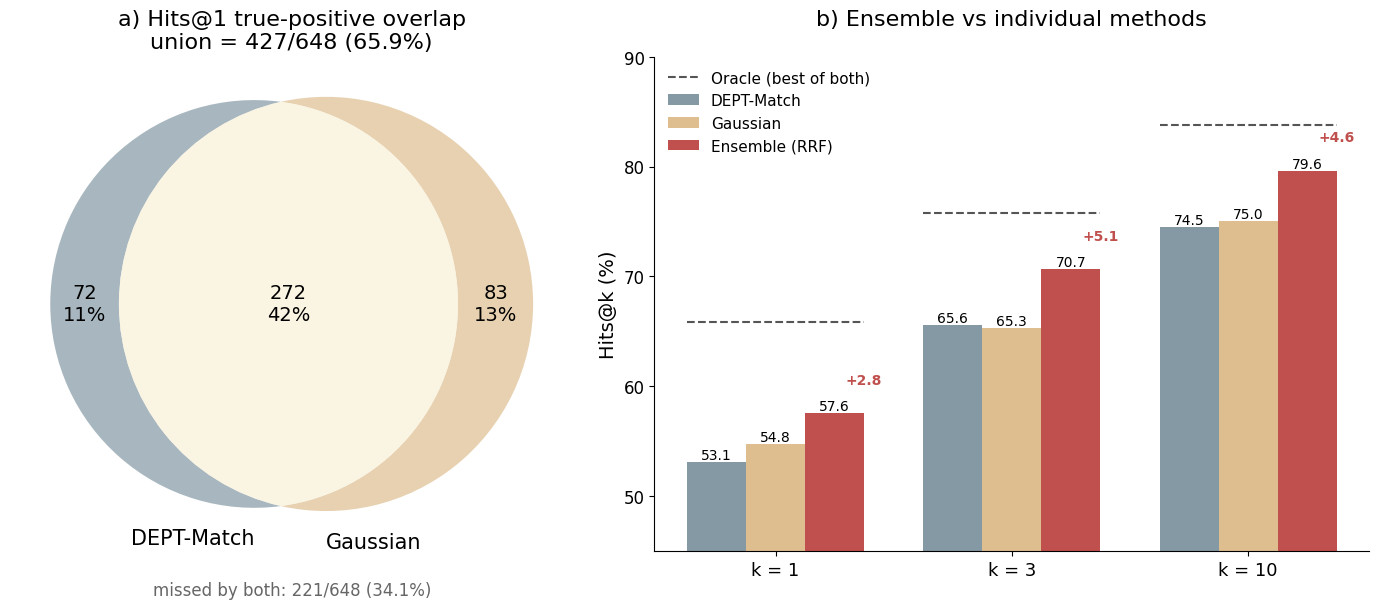

In [9]:
# Consistent colors: DEPT-Match = slate, Gaussian = amber, Ensemble = red.
DISPLAY = {"Hungarian (Cosine)": "DEPT-Match", "Gaussian (Cosine)": "Gaussian"}
METHOD_COLORS = {"Hungarian (Cosine)": "#8499a4", "Gaussian (Cosine)": "#debe8f"}
ENSEMBLE_COLOR = "#c0504d"

A, B = tp1["Hungarian (Cosine)"], tp1["Gaussian (Cosine)"]
only_a, both, only_b = len(A - B), len(A & B), len(B - A)
neither = N_TOTAL_QUERIES - len(union_tp1)

fig, (ax_v, ax_b) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [0.9, 1.1]})

# a) Venn of Hits@1 true positives (counts + % of all queries)
v = venn2(subsets=(only_a, only_b, both), set_labels=("DEPT-Match", "Gaussian"), ax=ax_v,
          set_colors=(METHOD_COLORS["Hungarian (Cosine)"], METHOD_COLORS["Gaussian (Cosine)"]), alpha=0.7)
for region, n in [("10", only_a), ("01", only_b), ("11", both)]:
    lab = v.get_label_by_id(region)
    if lab is not None:
        lab.set_text(f"{n}\n{100 * n / N_TOTAL_QUERIES:.0f}%")
        lab.set_fontsize(14)
for _t in v.set_labels:
    if _t is not None:
        _t.set_fontsize(15)
ax_v.set_title(f"a) Hits@1 true-positive overlap\nunion = {len(union_tp1)}/{N_TOTAL_QUERIES} "
               f"({100 * len(union_tp1) / N_TOTAL_QUERIES:.1f}%)", fontsize=16)
ax_v.text(0.5, -0.06, f"missed by both: {neither}/{N_TOTAL_QUERIES} "
          f"({100 * neither / N_TOTAL_QUERIES:.1f}%)", transform=ax_v.transAxes,
          ha="center", va="top", fontsize=12, color="#666666")

# b) individual vs ensemble Hits@k
ind = {lbl: get_metrics_at_k(df, query_spectra_df=query_spectra_df,
                             library_spectra_df=library_spectra_df, k_values=tuple(K_VALUES),
                             with_inchikey14=True, compute_tanimoto=False,
                             n_total_queries=N_TOTAL_QUERIES).set_index("k")["accuracy"]
       for lbl, df in fig5_ranked.items()}
ind["Ensemble (RRF)"] = ensemble_metrics.set_index("k")["accuracy"]

# Oracle = best-of-both union (upper bound the ensemble could reach) at each k.
oracle = {k: 100.0 * len(set().union(*[true_positive_set(df, k) for df in fig5_ranked.values()]))
          / N_TOTAL_QUERIES for k in K_VALUES}
best_single = {k: max(ind[lbl].get(k, 0.0) for lbl in fig5_ranked) for k in K_VALUES}

bar_labels = list(fig5_ranked.keys()) + ["Ensemble (RRF)"]
bar_colors = {**METHOD_COLORS, "Ensemble (RRF)": ENSEMBLE_COLOR}
disp = {**DISPLAY, "Ensemble (RRF)": "Ensemble (RRF)"}
x = np.arange(len(K_VALUES)); width = 0.25
n_bars = len(bar_labels)

for i, lbl in enumerate(bar_labels):
    y = [ind[lbl].get(k, 0.0) for k in K_VALUES]
    bars = ax_b.bar(x + i * width, y, width, label=disp[lbl], color=bar_colors[lbl])
    for bar, val in zip(bars, y):
        ax_b.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.1f}", ha="center",
                  va="bottom", fontsize=10)

# Ensemble gain (+Δ vs best single method), annotated above the red bars.
for xi, k in zip(x, K_VALUES):
    ens = ind["Ensemble (RRF)"][k]
    ax_b.text(xi + (n_bars - 1) * width + width / 2, ens + 2.4, f"+{ens - best_single[k]:.1f}",
              ha="center", va="bottom", fontsize=10, fontweight="bold", color=ENSEMBLE_COLOR)

# Oracle (best-of-both) reference line per k group.
for xi, k in zip(x, K_VALUES):
    ax_b.hlines(oracle[k], xi - width / 2, xi + (n_bars - 1) * width + width / 2,
                color="#555555", linestyle="--", linewidth=1.5, zorder=5)
ax_b.plot([], [], color="#555555", linestyle="--", linewidth=1.5, label="Oracle (best of both)")

y_hi = float(np.ceil((max(max(ind[l].get(k, 0.0) for l in bar_labels for k in K_VALUES),
                          max(oracle.values())) + 6) / 5) * 5)
ax_b.set_ylim(45, y_hi)
ax_b.locator_params(axis="y", nbins=5)
ax_b.set_xticks(x + width * (n_bars - 1) / 2)
ax_b.set_xticklabels([f"k = {k}" for k in K_VALUES], fontsize=13)
ax_b.tick_params(axis="y", labelsize=12)
ax_b.set_ylabel("Hits@k (%)", fontsize=14)
# Trailing blank line keeps this single-line title's baseline level with panel a's two-line title.
ax_b.set_title("b) Ensemble vs individual methods\n ", fontsize=16)
ax_b.legend(frameon=False, fontsize=11, loc="upper left")
ax_b.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(f"{PROCESSED_DATA_DIR}/../figures/figure5_ensemble.png", dpi=400, bbox_inches="tight")
plt.show()

## 9 · Effect of knowing the molecular formula

If the query's molecular formula is known (e.g. from HRMS), the reference
library can be restricted to compounds with **the same formula** before
scoring. Formulas are computed from SMILES with RDKit (cached), and each query
is scored only against its same-formula library entries. We compare the
unrestricted benchmark (Figure 2) with this formula-restricted search.

In [10]:
from collections import defaultdict

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

from dept_similarity.constants import CACHE_DIR


def _formula(smiles):
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) else None
    return rdMolDescriptors.CalcMolFormula(mol) if mol is not None else None


# Library formulas (cached — RDKit is fast but this avoids recomputing on rerun).
_formula_cache = Path(CACHE_DIR) / "library_formula.parquet"
if _formula_cache.exists():
    _fdf = pd.read_parquet(_formula_cache)
    lib_formula = dict(zip(_fdf["compound_id"], _fdf["formula"]))
else:
    _forms = Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
        delayed(_formula)(s) for s in library_spectra_df["smiles"])
    lib_formula = dict(zip(library_spectra_df["compound_id"], _forms))
    pd.DataFrame({"compound_id": list(lib_formula), "formula": list(lib_formula.values())}
                 ).to_parquet(_formula_cache, index=False)

query_formula = {cid: _formula(smi)
                 for cid, smi in zip(query_spectra_df["compound_id"], query_spectra_df["smiles"])}

formula_group = defaultdict(list)
for cid, f in lib_formula.items():
    if f:
        formula_group[f].append(cid)

# Same-formula candidate set for each query that survived the prefilter benchmark.
FORMULA_PAIRS = {qid: formula_group.get(query_formula.get(qid), []) for qid in query_ids}
_sizes = [len(v) for v in FORMULA_PAIRS.values()]
_true_kept = sum(q_true_key.get(qid) in {c.split("_")[-1] for c in FORMULA_PAIRS[qid]}
                 for qid in query_ids)
print({"queries": len(query_ids),
       "same_formula_cands_per_query_median": int(np.median(_sizes)),
       "same_formula_cands_per_query_mean": round(float(np.mean(_sizes)), 0),
       "true_match_retained": f"{_true_kept}/{len(query_ids)}"})

{'queries': 639, 'same_formula_cands_per_query_median': 28, 'same_formula_cands_per_query_mean': 79.0, 'true_match_retained': '639/639'}


In [11]:
# Re-score the two strongest methods against only the same-formula candidates.
def _formula_rank_hungarian(qid):
    cand = sorted(FORMULA_PAIRS.get(qid, []))
    if not cand:
        return None
    qp = QUERY_PEAKS[qid]
    cos = np.empty(len(cand))
    for i, c in enumerate(cand):
        res = align_dept_peaks_hungarian(qp, LIBRARY_PEAKS[c],
                                         ppm_tolerance=HUNG_TOL, match_multiplicity=True)
        cos[i] = cosine_from_alignment(res, 1)
    return _rank_row(qid, "cosine", cos, cand)


def _formula_rank_gauss(qid):
    cand = sorted(FORMULA_PAIRS.get(qid, []))
    if not cand:
        return None
    qv = generate_gaussian_vector(QUERY_PEAKS[qid], sigma=GAUSS_SIGMA)
    qn = float(np.linalg.norm(qv)) or 1.0
    cos = np.empty(len(cand))
    for i, c in enumerate(cand):
        cv = generate_gaussian_vector(LIBRARY_PEAKS[c], sigma=GAUSS_SIGMA)
        cn = float(np.linalg.norm(cv))
        cos[i] = float(cv @ qv) / (cn * qn) if cn > 0 else 0.0
    return _rank_row(qid, "cosine", cos, cand)


formula_runs = {"Hungarian (Cosine)": _formula_rank_hungarian,
                "Gaussian (Cosine)": _formula_rank_gauss}
formula_metrics = {}
for lbl, worker in formula_runs.items():
    rows = [r for r in Parallel(n_jobs=N_JOBS, backend="multiprocessing")(
        delayed(worker)(qid) for qid in query_ids) if r]
    formula_metrics[lbl] = get_metrics_at_k(
        pd.DataFrame(rows), query_spectra_df=query_spectra_df,
        library_spectra_df=library_spectra_df, k_values=tuple(K_VALUES),
        with_inchikey14=True, compute_tanimoto=False, n_total_queries=N_TOTAL_QUERIES
    ).set_index("k")["accuracy"]

# Unrestricted (Figure 2) numbers for the same methods, same denominator.
unrestricted = {lbl: get_metrics_at_k(
    fig5_ranked[lbl], query_spectra_df=query_spectra_df, library_spectra_df=library_spectra_df,
    k_values=tuple(K_VALUES), with_inchikey14=True, compute_tanimoto=False,
    n_total_queries=N_TOTAL_QUERIES).set_index("k")["accuracy"]
    for lbl in formula_runs}

formula_effect_df = pd.DataFrame({
    (lbl, cond): (unrestricted if cond == "full library" else formula_metrics)[lbl]
    for lbl in formula_runs for cond in ("full library", "same formula")
}).T
formula_effect_df.columns = [f"Hits@{k} (%)" for k in K_VALUES]
formula_effect_df.round(1)

Hits@1 (%)  Hits@3 (%)  Hits@10 (%)
Hungarian (Cosine) full library        53.1        65.6         74.5
                   same formula        84.3        95.1         98.0
Gaussian (Cosine)  full library        54.8        65.3         75.0
                   same formula        86.3        94.3         96.8

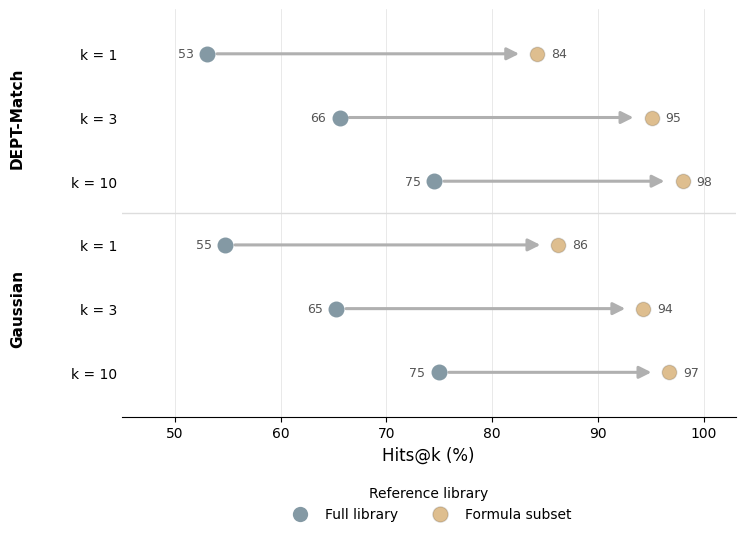

In [12]:
# Formula effect — dumbbell: full library ● ──▶ ● same formula, per (method, k).
from matplotlib.lines import Line2D

FULL_COLOR = "#8499a4"     # slate
FORMULA_COLOR = "#debe8f"  # amber
disp = {"Hungarian (Cosine)": "DEPT-Match", "Gaussian (Cosine)": "Gaussian"}
methods = list(formula_runs)
rows = [(m, k) for m in methods for k in K_VALUES]
y = np.arange(len(rows))[::-1]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for yi, (m, k) in zip(y, rows):
    f = float(unrestricted[m][k])
    s = float(formula_metrics[m][k])
    ax.annotate("", xy=(s, yi), xytext=(f, yi),
                arrowprops=dict(arrowstyle="-|>", color="#b0b0b0", lw=2.2,
                                mutation_scale=18, shrinkA=7, shrinkB=13))
    ax.scatter([f], [yi], s=110, color=FULL_COLOR, zorder=3)
    ax.scatter([s], [yi], s=110, color=FORMULA_COLOR, edgecolor="#00000022", zorder=3)
    ax.text(f - 1.3, yi, f"{f:.0f}", ha="right", va="center", fontsize=9, color="#555555")
    ax.text(s + 1.3, yi, f"{s:.0f}", ha="left", va="center", fontsize=9, color="#555555")

ax.set_yticks(y)
ax.set_yticklabels([f"k = {k}" for (_m, k) in rows], fontsize=10)
ax.set_ylim(-0.7, len(rows) - 0.3)
ax.set_xlim(45, 103)
ax.set_xlabel("Hits@k (%)", fontsize=12)

# Method group labels + separator between the two methods.
n_k = len(K_VALUES)
for gi, m in enumerate(methods):
    lanes = y[gi * n_k:(gi + 1) * n_k]
    ax.text(-0.17, float(np.mean(lanes)), disp[m], transform=ax.get_yaxis_transform(),
            ha="center", va="center", fontsize=11, fontweight="bold", rotation=90)
if len(methods) > 1:
    ax.axhline(y[n_k] + 0.5, color="#dddddd", lw=1.0)

# Circle legend handles to match the scatter markers (not square patches).
_leg_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=11,
           markerfacecolor=FULL_COLOR, markeredgecolor="none", label="Full library"),
    Line2D([0], [0], marker="o", linestyle="none", markersize=11,
           markerfacecolor=FORMULA_COLOR, markeredgecolor="#00000022", label="Formula subset"),
]
ax.legend(handles=_leg_handles, title="Reference library", frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=10)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", linewidth=0.5, color="lightgray", alpha=0.7)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(f"{PROCESSED_DATA_DIR}/../figures/figure4.png", dpi=400, bbox_inches="tight")
plt.show()